In [2]:
%load_ext autoreload
%autoreload 2

**In case of problems or questions, please first check the list of [Frequently Asked Questions (FAQ)](https://stardist.net/docs/faq.html).**

Please shutdown all other training/prediction notebooks before running this notebook (as those might occupy the GPU memory otherwise).

In [5]:
from __future__ import print_function, unicode_literals, absolute_import, division
import sys
import numpy as np
import matplotlib
matplotlib.rcParams["image.interpolation"] = 'none'
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from glob import glob
from skimage import io
from csbdeep.utils import Path, normalize
from csbdeep.io import save_tiff_imagej_compatible

from stardist import random_label_cmap, _draw_polygons, export_imagej_rois
from stardist.models import StarDist2D

np.random.seed(6)
lbl_cmap = random_label_cmap()

# Data

We assume that data has already been downloaded in via notebook [1_data.ipynb](1_data.ipynb).  
We now load images from the sub-folder `test` that have not been used during training.

In [7]:
X = sorted(glob('/hpc/group/yizhanglab/zs144/Zion-ZhangLab/experiments/EXP004/output/240819_Ji_N1_H_EScan/patches_2048/*.png'))
X = [io.imread(x) for x in X]
X = X[:50]
Y = sorted(glob('/hpc/group/yizhanglab/zs144/Zion-ZhangLab/experiments/EXP004/output/240819_Ji_N1_H_EScan/pseudo_gt_masks_2048/*.png'))
Y = [io.imread(y) for y in Y]
Y = Y[:50]

rng = np.random.RandomState(42)
ind = rng.permutation(len(X))
n_test = max(1, int(round(0.15 * len(ind))))
ind_train, ind_test = ind[:-n_test], ind[-n_test:]
X_test, Y_test = [X[i] for i in ind_test]  , [Y[i] for i in ind_test]
X_trn, Y_trn = [X[i] for i in ind_train], [Y[i] for i in ind_train]

n_channel = 1 if X_test[0].ndim == 2 else X_test[0].shape[-1]
axis_norm = (0,1)   # normalize channels independently
# axis_norm = (0,1,2) # normalize channels jointly
if n_channel > 1:
    print("Normalizing image channels %s." % ('jointly' if axis_norm is None or 2 in axis_norm else 'independently'))

Normalizing image channels independently.


In [3]:
# # show all test images
# if False:
#     fig, ax = plt.subplots(7,8, figsize=(16,16))
#     for i,(a,x) in enumerate(zip(ax.flat, X)):
#         a.imshow(x if x.ndim==2 else x[...,0], cmap='gray')
#         a.set_title(i)
#     [a.axis('off') for a in ax.flat]
#     plt.tight_layout()
# None;

# Load trained model

If you trained your own StarDist model (and optimized its thresholds) via notebook [2_training.ipynb](2_training.ipynb), then please set `demo_model = False` below.

In [8]:
demo_model = True

if demo_model:
    print (
        "NOTE: This is loading a previously trained demo model!\n"
        "      Please set the variable 'demo_model = False' to load your own trained model.",
        file=sys.stderr, flush=True
    )
    model = StarDist2D.from_pretrained('2D_versatile_he')
else:
    model = StarDist2D(None, name='stardist', basedir='models')
None;

NOTE: This is loading a previously trained demo model!
      Please set the variable 'demo_model = False' to load your own trained model.


Found model '2D_versatile_he' for 'StarDist2D'.
5294730/5294730 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


I0000 00:00:1738877699.595707 2115064 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22395 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:04:00.0, compute capability: 8.6


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.692478, nms_thresh=0.3.


## Prediction

Make sure to normalize the input image beforehand or supply a `normalizer` to the prediction function.

Calling `model.predict_instances` will
- predict object probabilities and star-convex polygon distances (see `model.predict` if you want those)
- perform non-maximum suppression (with overlap threshold `nms_thresh`) for polygons above object probability threshold `prob_thresh`.
- render all remaining polygon instances in a label image
- return the label instances image and also the details (coordinates, etc.) of all remaining polygons

In [9]:
img = normalize(X[0], 1, 99.8, axis=axis_norm)
labels, details = model.predict_instances(img)

functional.py (237): The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 2048, 2048, 3))
I0000 00:00:1738877728.114358 2119160 service.cc:148] XLA service 0x7f6e2000bb90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738877728.115213 2119160 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A5000, Compute Capability 8.6
2025-02-06 16:35:28.730202: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738877729.205813 2119160 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-02-06 16:35:40.451487: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng33{k2=2,k6=0,k13=1,k14=0,k22=1} for conv (f32[1,32,2048,2048]{3,2,1,0}, u8[0]{0}) custom-call(f32[1,3,2048,2048]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3

In [12]:
img.ndim

3

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.0].


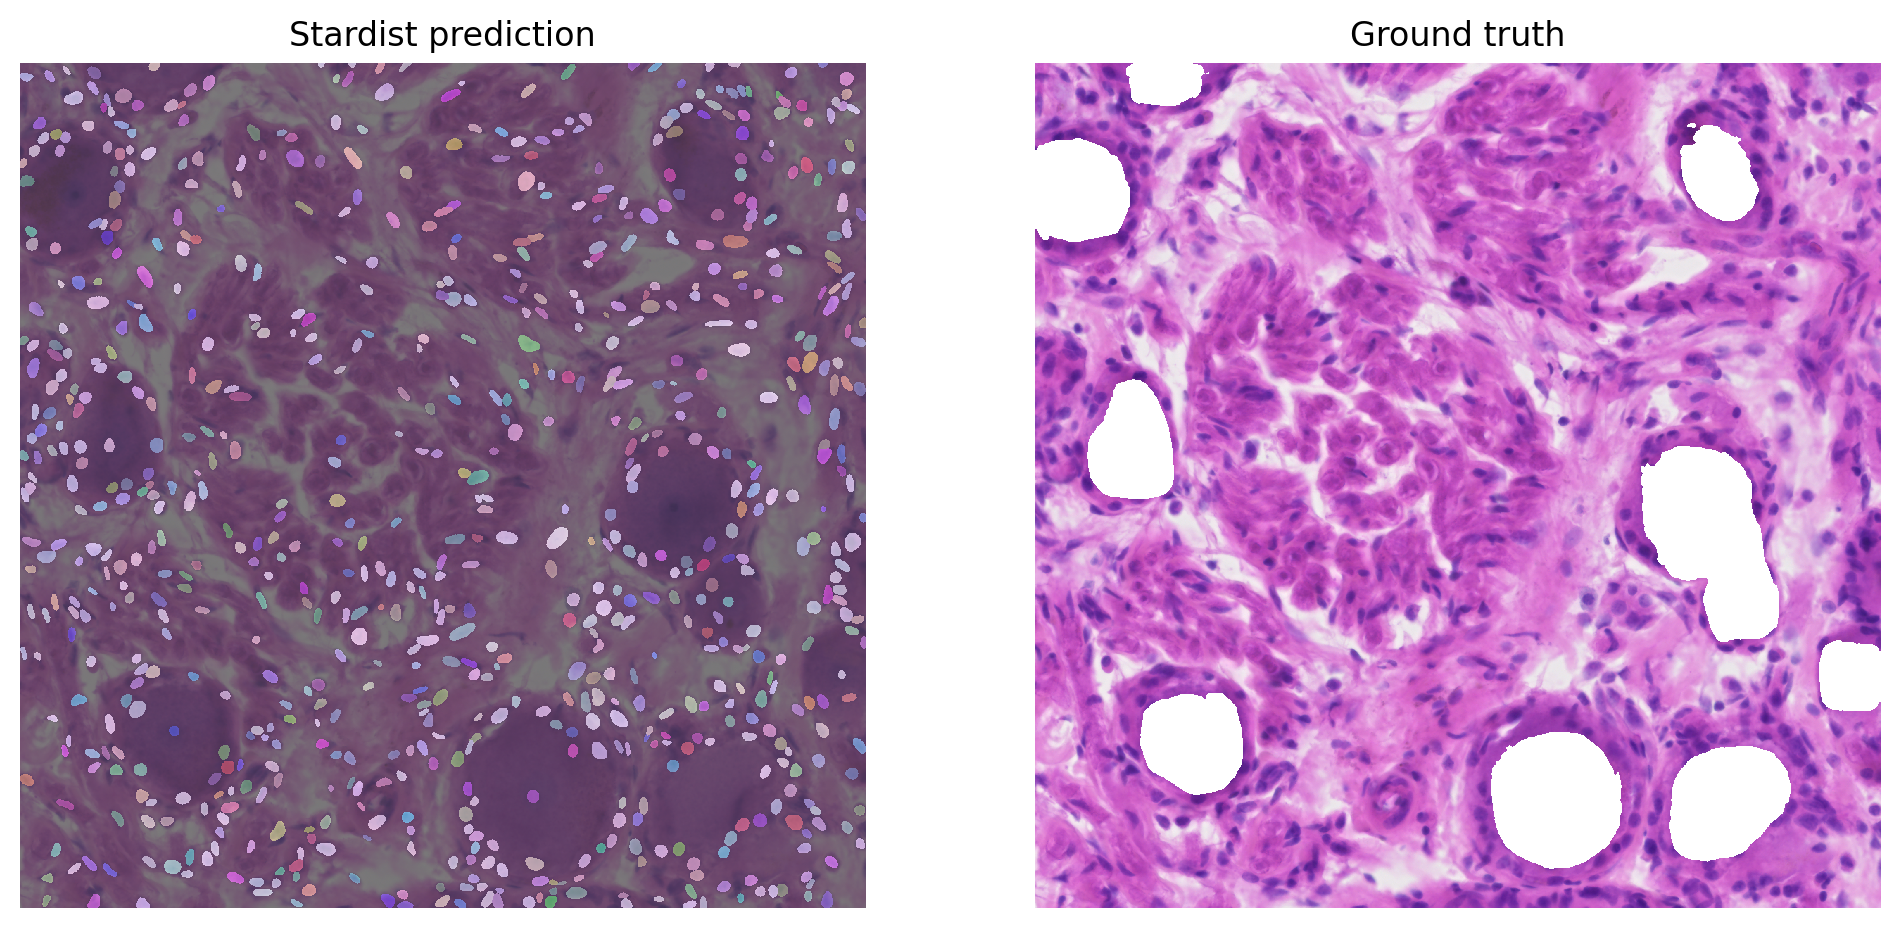

In [21]:
image = X[0]
gt_mask = Y[0]

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].imshow(image, alpha=0.7)
axes[0].imshow(labels, cmap=lbl_cmap, alpha=0.5)
axes[0].set_title("Stardist prediction")
axes[0].axis('off')
axes[1].imshow(image)
color = np.array([251 / 255, 252 / 255, 30 / 255, 0.6])
h, w = gt_mask.shape[-2:]
show_gt_mask = gt_mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
axes[1].imshow(show_gt_mask)
axes[1].axis('off')
axes[1].set_title("Ground truth");

## Save predictions

Uncomment the lines in the following cell if you want to save the example image and the predictions to disk.  
See [this notebook](../other2D/export_imagej_rois.ipynb) for more details on how to export ImageJ ROIs.

In [7]:
# save_tiff_imagej_compatible('example_image.tif', img, axes='YX')
# save_tiff_imagej_compatible('example_labels.tif', labels, axes='YX')
# export_imagej_rois('example_rois.zip', details['coord'])

# Example results

In [8]:
def example(model, i, show_dist=True):
    img = normalize(X[i], 1,99.8, axis=axis_norm)
    labels, details = model.predict_instances(img)

    plt.figure(figsize=(13,10))
    img_show = img if img.ndim==2 else img[...,0]
    coord, points, prob = details['coord'], details['points'], details['prob']
    plt.subplot(121); plt.imshow(img_show, cmap='gray'); plt.axis('off')
    a = plt.axis()
    _draw_polygons(coord, points, prob, show_dist=show_dist)
    plt.axis(a)
    plt.subplot(122); plt.imshow(img_show, cmap='gray'); plt.axis('off')
    plt.imshow(labels, cmap=lbl_cmap, alpha=0.5)
    plt.tight_layout()
    plt.show()

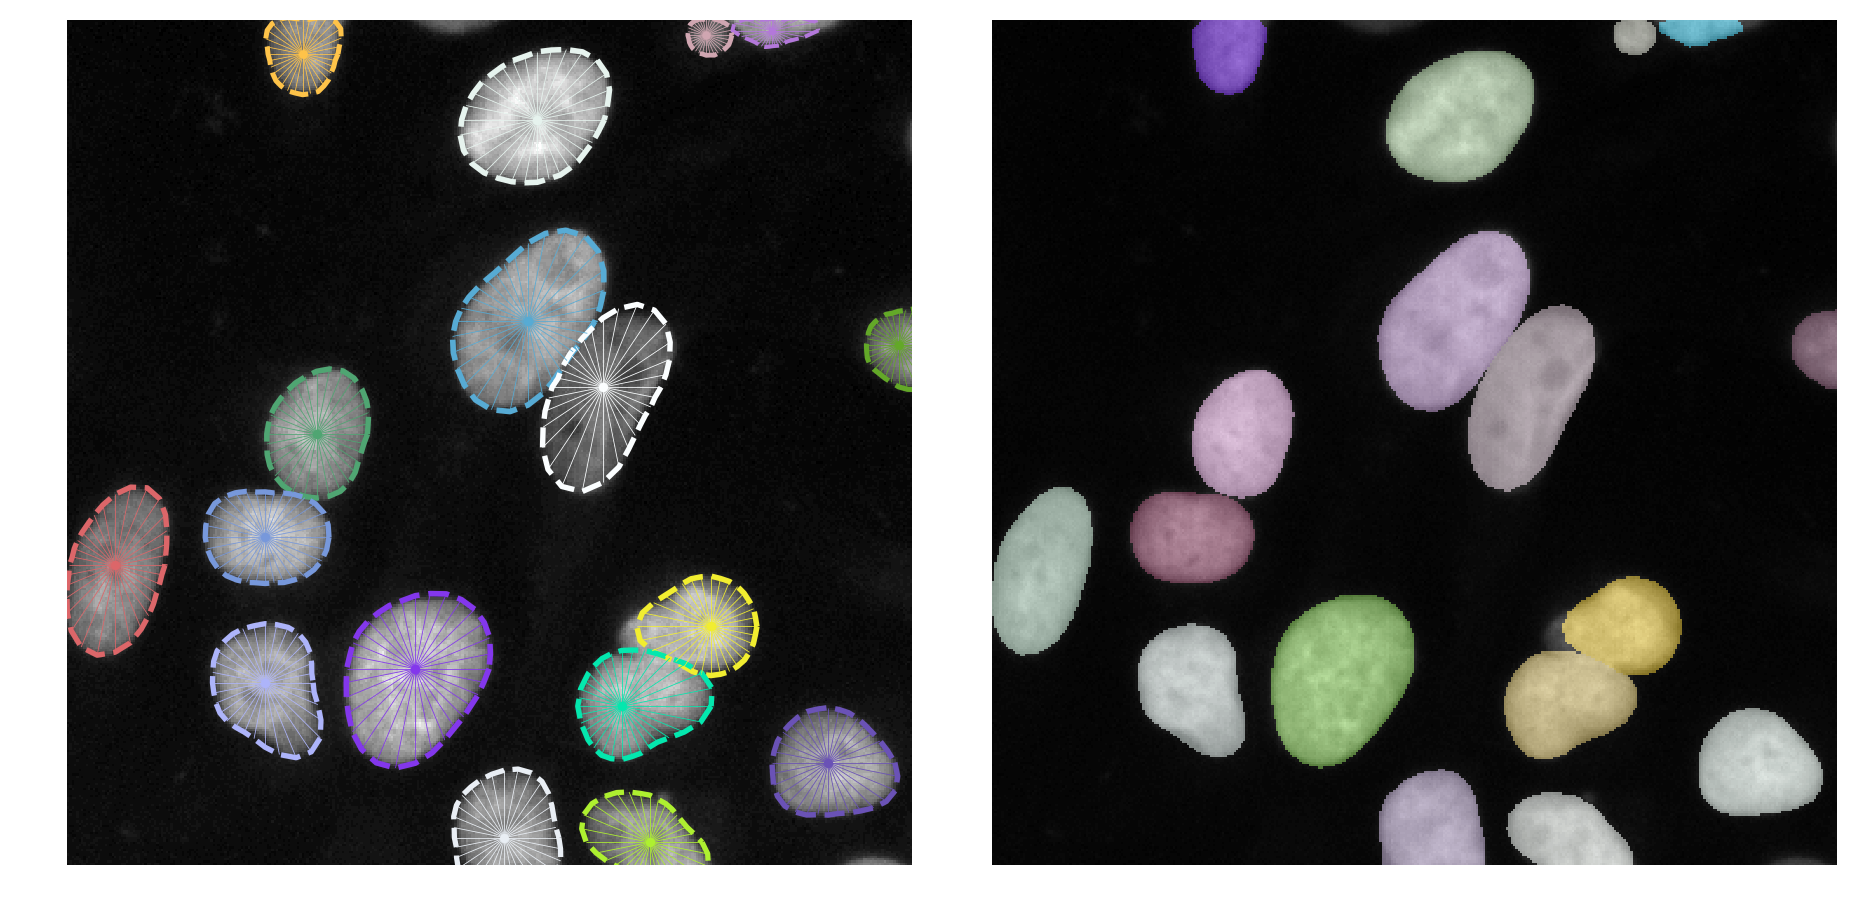

In [9]:
example(model, 42)

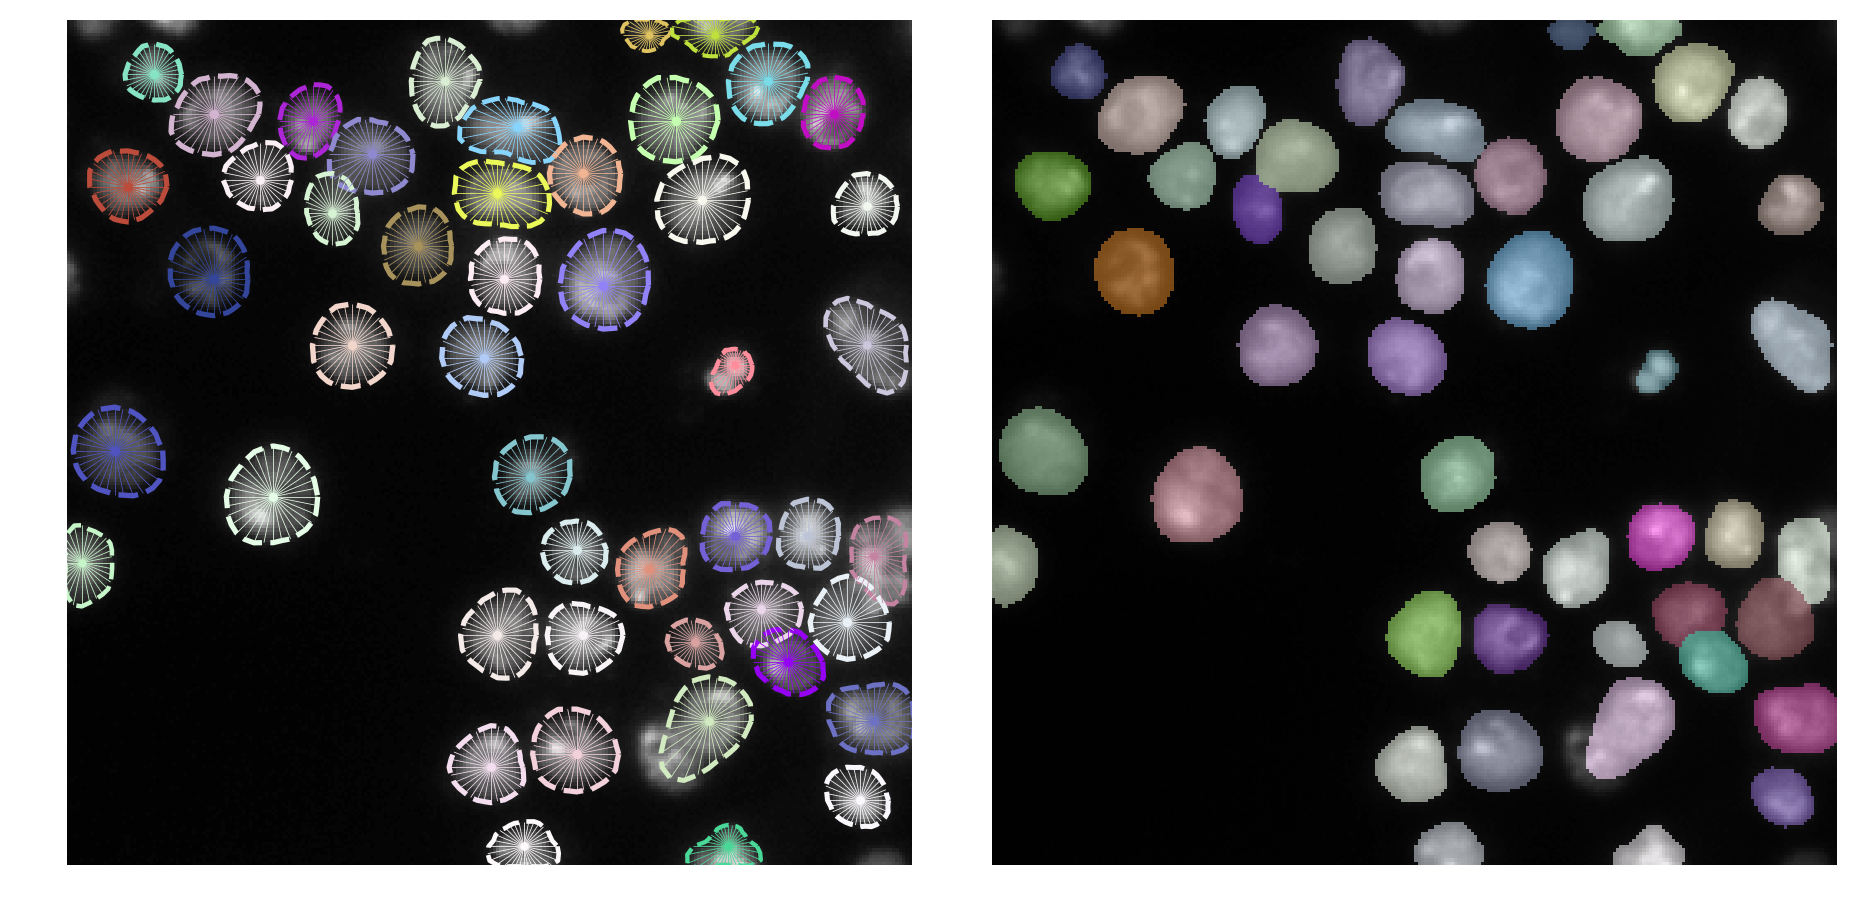

In [10]:
example(model, 1)

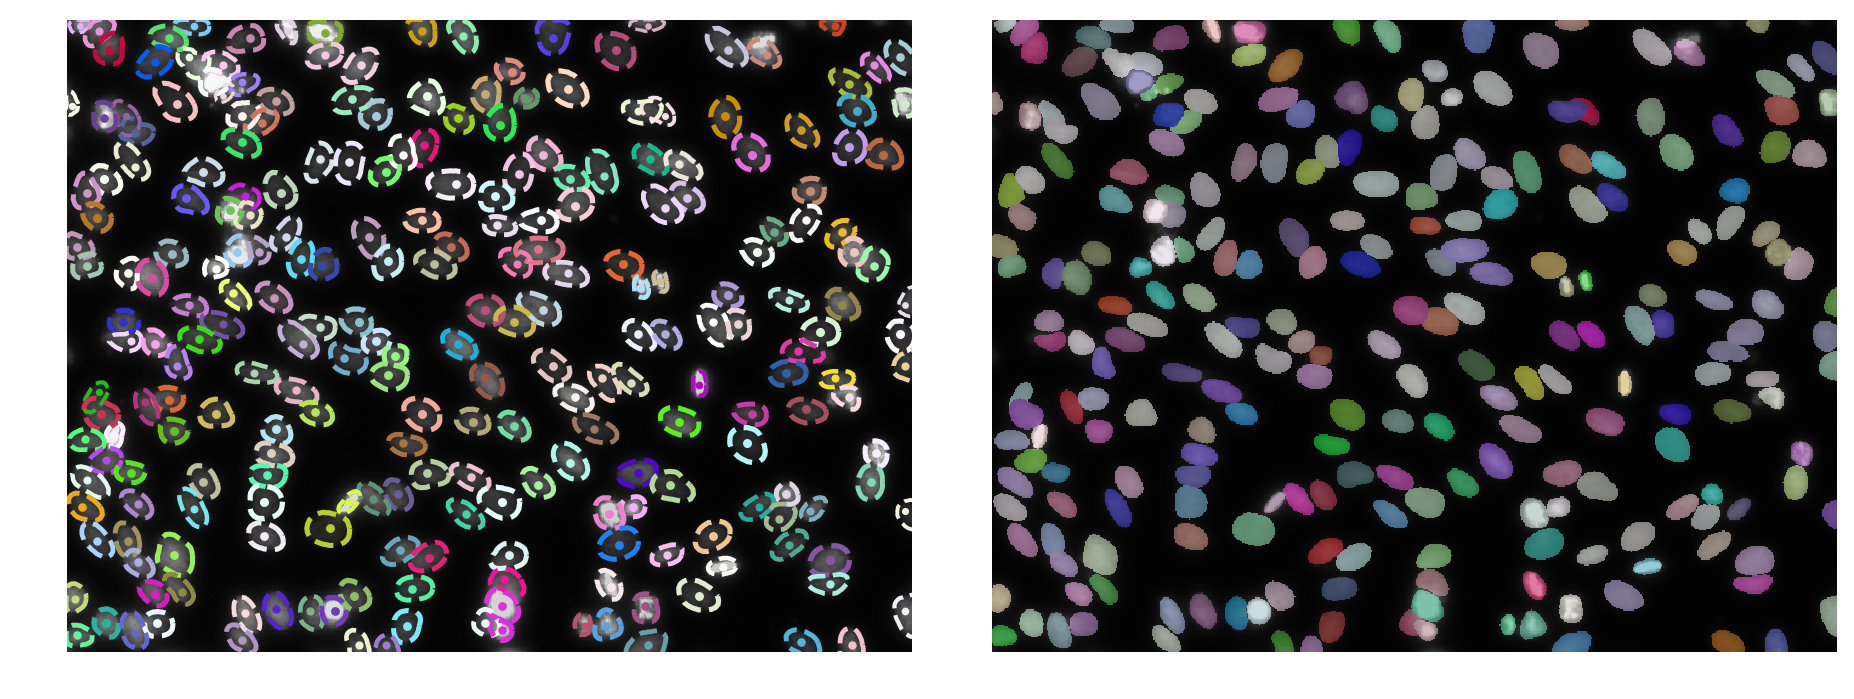

In [11]:
example(model, 15, False)

# Model from paper

In [12]:
model_paper = StarDist2D.from_pretrained('2D_paper_dsb2018')

Found model '2D_paper_dsb2018' for 'StarDist2D'.
Loading network weights from 'weights_last.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.417819, nms_thresh=0.5.


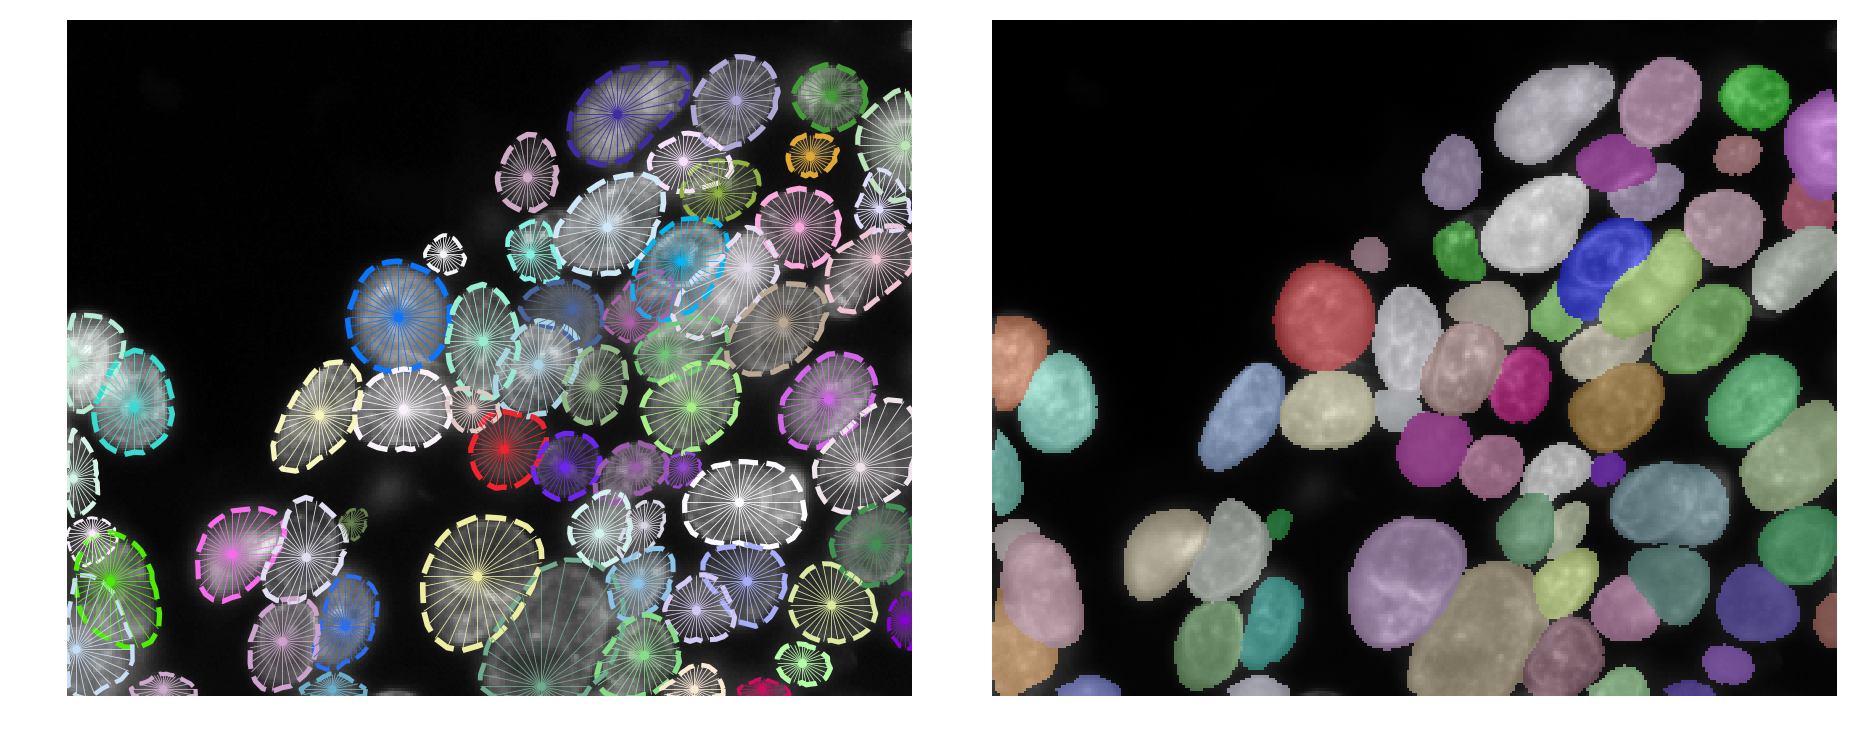

In [13]:
example(model_paper, 29)

# Versatile model

Try this model first if you have images that look similar to the training data in this example.

In [14]:
model_versatile = StarDist2D.from_pretrained('2D_versatile_fluo')

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


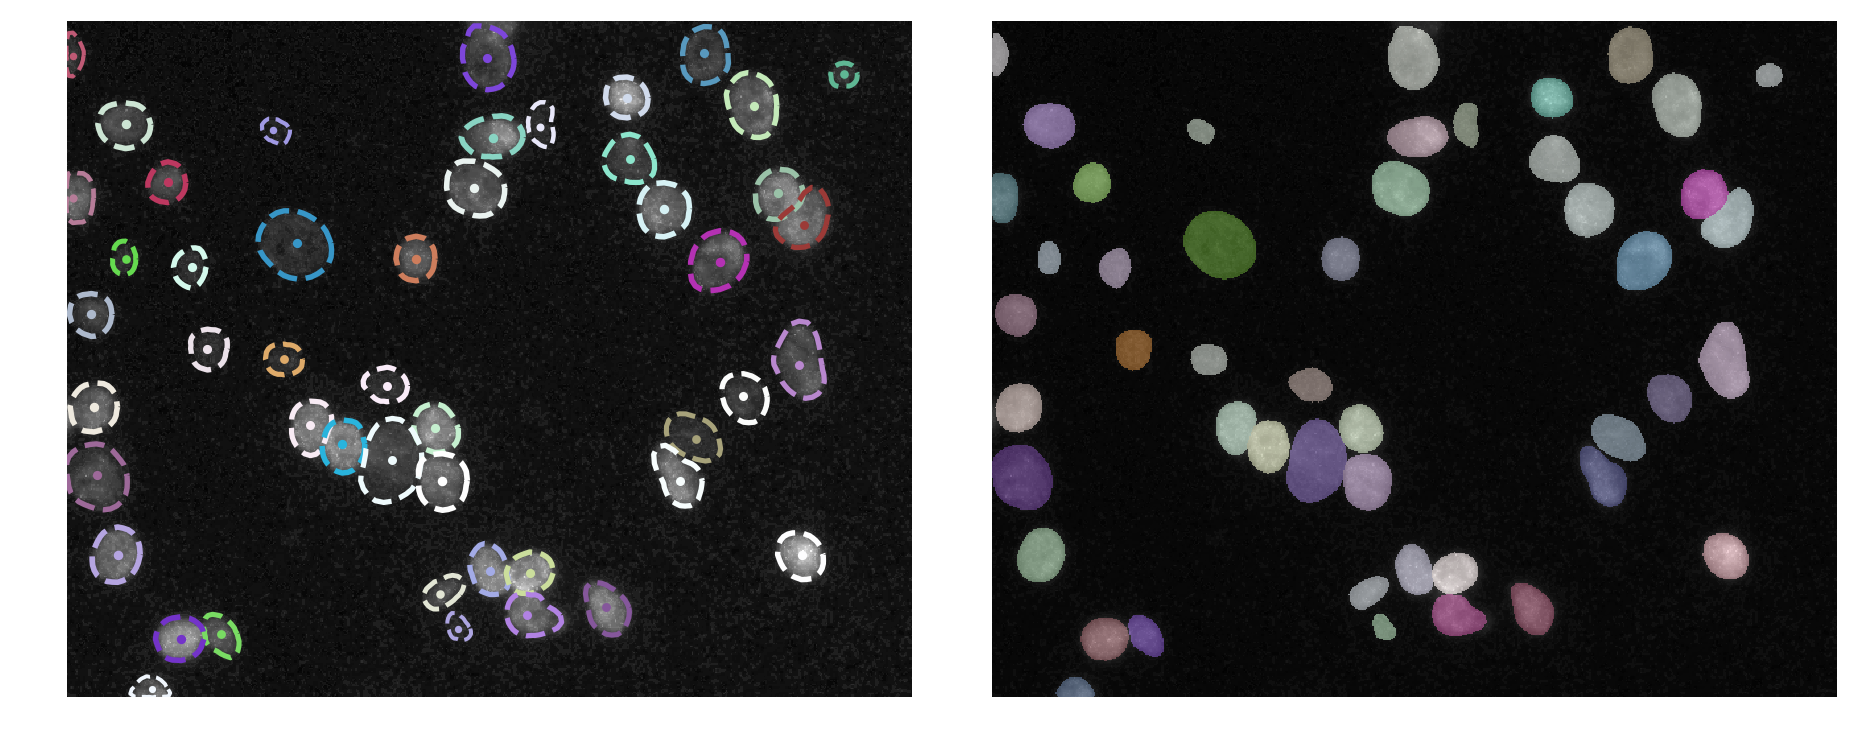

In [15]:
example(model_versatile, 30, False)

Show all available pretrained models:

In [16]:
StarDist2D.from_pretrained()

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None
